In [1]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.cm as color
better_magma = color.magma
better_magma.set_bad('black',1.)
import matplotlib.colors as c

from prysm import (
    mathops, 
    conf,
)
from prysm.mathops import (
    _np,
    np,
    fft,
    interpolate,
    ndimage,
)
from prysm.coordinates import (
    make_xy_grid, 
    cart_to_polar,
)
from prysm.propagation import Wavefront as WF
from prysm.propagation import (
    focus_fixed_sampling,
    focus_fixed_sampling_backprop
)                              
from prysm.thinlens import (
    defocus_to_image_displacement,
    image_displacement_to_defocus,
)
from prysm.geometry import (
    offset_circle,
    circle,
    spider,
    gaussian,
)
from prysm.polynomials import (
    lstsq,
    noll_to_nm,
    zernike_nm,
    zernike_nm_seq,
    hopkins,
    sum_of_2d_modes,
    sum_of_2d_modes_backprop
)
mathops.set_backend_to_cupy()
# conf.config.precision = 32

from astropy.io import (
    fits,
    ascii,
)

from skimage.measure import centroid

import copy

from algos import BING_BONG, FFPR2, PDPR, model, mean_squared_error, gain_invariant_error
import utils

from functools import partial

from lina.utils import TikhonovInverse

import config_um
import config_um_wcc
from Batoid4LOFT.LAZULI_STOP_mark11 import Lazuli_stop, readBulkMotion, readDeformation

from psd_utils import PSDUtils

from scipy.optimize import minimize

from scipy.interpolate import RegularGridInterpolator

from tqdm import tqdm

from psd_utils import PSDUtils

from model import telescope
# from algos import pdpr, OPD, ADPR
import utils

from functools import partial

from opt import F77LBFGSB, runN, RAdam
from IPython.display import clear_output

# logging stuff
import logging
psd_log = logging.getLogger('__psd_utils__')
psd_log.disabled = True

%reload_ext autoreload
%autoreload 2
%matplotlib inline

import toml

In [2]:
!nvidia-smi

Tue May  5 16:27:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:25:00.0 Off |                    0 |
| N/A   32C    P0             97W /  300W |    4490MiB /  81920MiB |     30%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## SETUP MODEL

In [3]:
config = toml.load('/home/derbyk/src/ffpr/data/3m_off_axis_default.toml')
optic_opd_data = utils.load_pickle('/home/derbyk/src/ffpr/data/opd_maps.pkl')

sys = telescope(config=config, optic_opd_data=optic_opd_data)

dark = sys.get_dark(stacked_frames=1)
images = [im - dark for im in sys.snap(stacked_frames=1)]

for i, im in enumerate(images):
    print(f'Image {i + 1:02.0f} SNR = {im.max() / dark.std():.1f}')

Image 01 SNR = 673.8
Image 02 SNR = 993.9
Image 03 SNR = 586.4
Image 04 SNR = 1260.6
Image 05 SNR = 688.7
Image 06 SNR = 650.5
Image 07 SNR = 1158.3


## PLOT PSFS

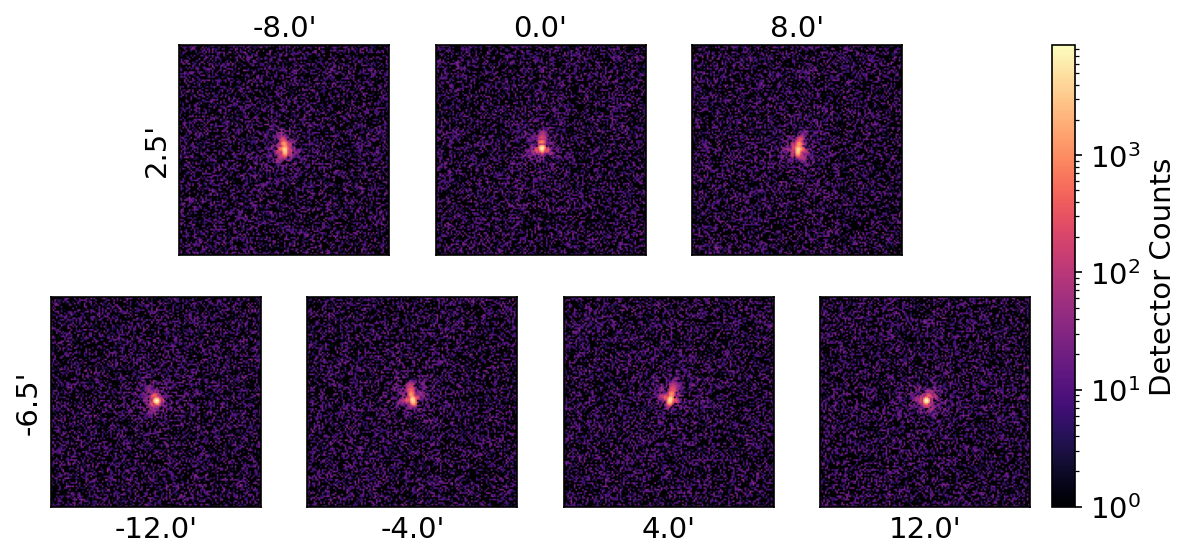

In [4]:
pupil = sys.pupil
fields = [(sys.cfg['sources'][src]['position_x'], sys.cfg['sources'][src]['position_y']) for src in sys.cfg['sources']]

utils.plot_psfs_7(psfs=images, fields=fields)

## PLOT WFES

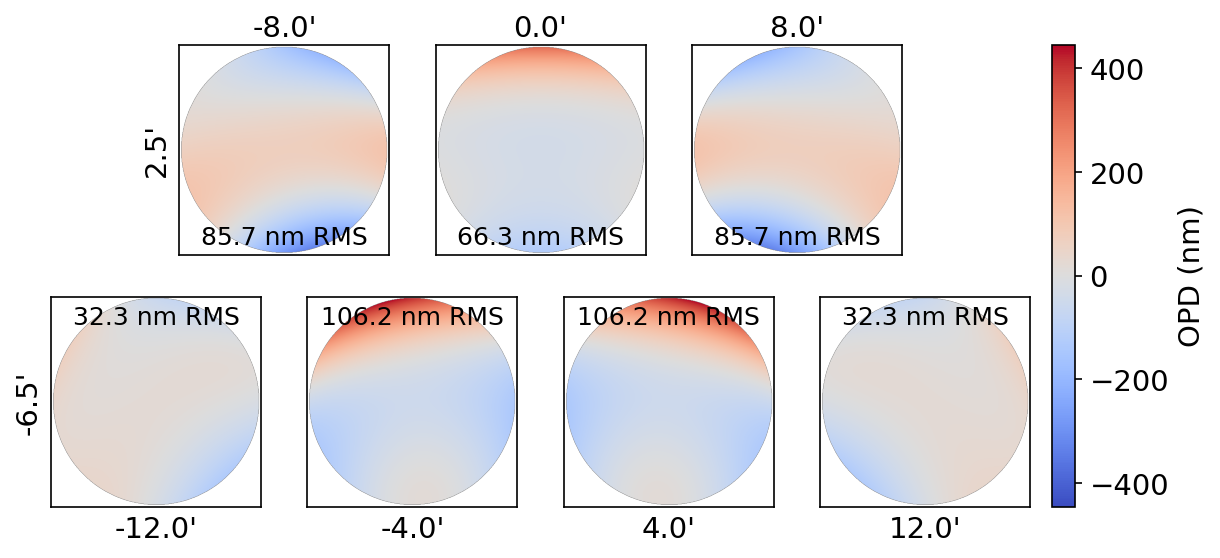

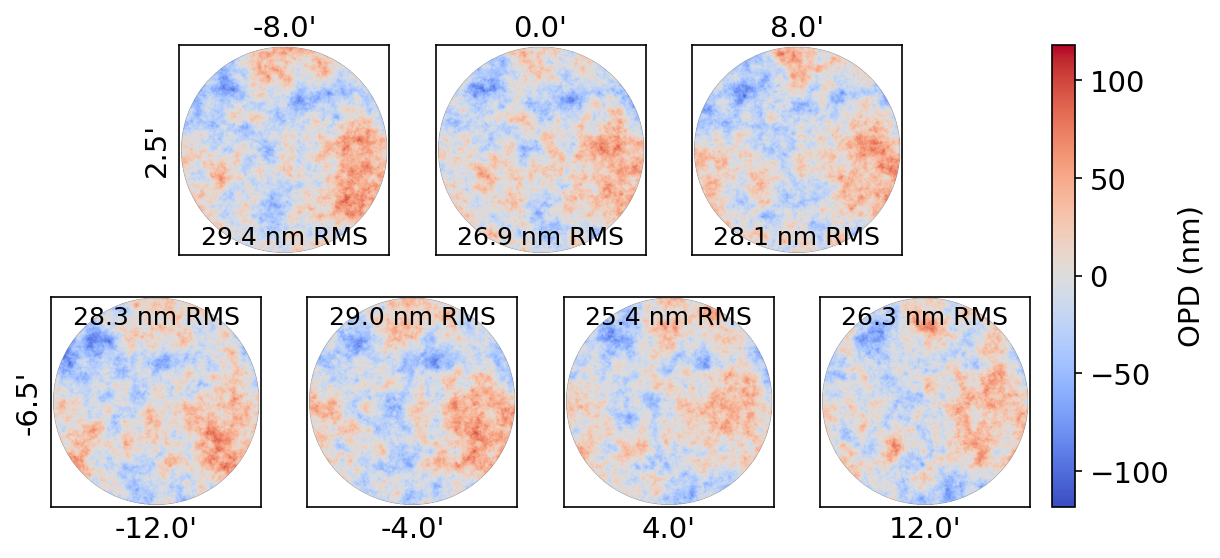

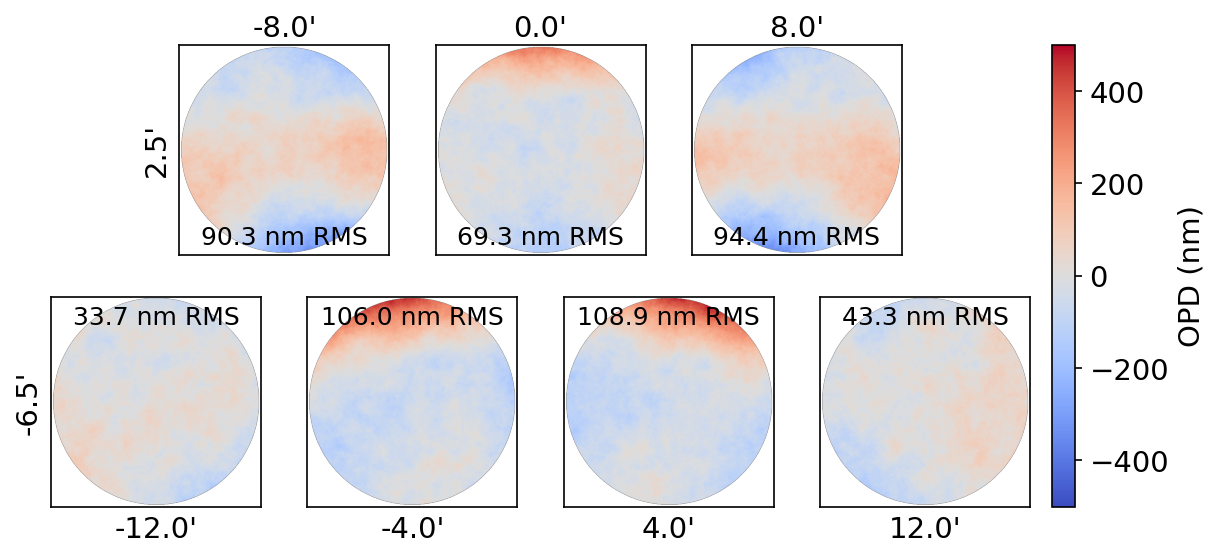

In [5]:
opds_fields = copy.deepcopy(sys.opds_field)
opds_optics = copy.deepcopy(sys.opds_optics)
opds_truths = [opd_field + opd_optics for (opd_field, opd_optics) in zip(opds_fields, opds_optics)]

opds_fields_nominal = opds_fields

utils.plot_opds_7(opds=opds_fields, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_optics, pupil=pupil, fields=fields)
utils.plot_opds_7(opds=opds_truths, pupil=pupil, fields=fields)

## SEMICIRCLE FOV

Telescope designed with semicircle FOV in mind. Recreated here so that random source positions fall within this region. See "Large Etendue 3-Meter Unobscured Three Mirror Anastigmat Telescope for Astrophysics" by Kim et al. 2025 for more details.

Text(0.5, 1.0, 'Telescope Semicircle FOV')

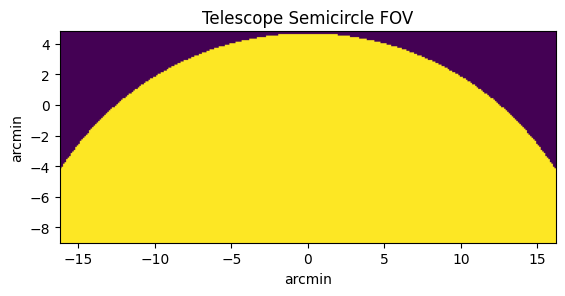

In [6]:
fx = np.linspace(-16.2, 16.2, 325)
fy = np.linspace(-9.0, 4.8, 139)

Fx, Fy = np.meshgrid(fx, fy)

semicirc_fov = np.sqrt(Fx ** 2 + (Fy + 14.5) ** 2) <= 19.2
Fx_valid = Fx[semicirc_fov]
Fy_valid = Fy[semicirc_fov]

plt.imshow(semicirc_fov.get(), extent=[fx.min().get(), fx.max().get(), fy.min().get(), fy.max().get()])
plt.xlabel('arcmin')
plt.ylabel('arcmin')
plt.title('Telescope Semicircle FOV')

## MONTE CARLO

In [7]:
misalignments = utils.load_pickle('/home/derbyk/src/ffpr/data/misalignments_cases_100_dec_50um_tilt_5as.pkl')

In [13]:
# SNR threshold
snr_thresh = 5

# number of sources
n_sources = 5

# system stuff
efl = sys.cfg['general']['f_eff']
pupil_dx = sys.cfg['optics']['m1']['diam'] / sys.cfg['general']['npix_pupil']
focal_dx = sys.cfg['detector']['dx_focal']

# set rng for repeatability on source positions
rng = np.random.default_rng(seed=73)

# stuff to save
data = {}

case = 1

for m in misalignments:

    print(f'CASE {case:03.0f} ----------------------------------')
    print()

    # get random source positions
    inds = rng.integers(low=0, high=Fx_valid.size, size=n_sources)
    new_positions = [(float(Fx_valid[i]), float(Fy_valid[i])) for i in inds]
    mags = [17 for _ in range(n_sources)]

    # send positions to model 
    sys.set_source_parameters(magnitudes=mags, positions=new_positions)

    # reset optics to nominal alignment
    sys.reset_optics()

    # get field dependent OPD at nominal alignment
    opds_fields_nominal = copy.deepcopy(sys.opds_field)

    # calculate RMS of diversity per field
    # diversity comes from field dependent OPD at nominal alignment
    rms_diversity_per_field = []
    for opd in opds_fields_nominal:
        opd -= np.mean(opd[pupil])
        rms_diversity_per_field.append(float(np.sqrt(np.mean(opd[pupil] ** 2))))

    # apply misalignment
    sys.move_optics(M1_motion=m['M1'], M2_motion=m['M4'], M3_motion=m['M4'], M4_motion=m['M4'])

    # get total OPDs per field
    opds_fields = copy.deepcopy(sys.opds_field)
    opds_optics = copy.deepcopy(sys.opds_optics)
    opds_truths = [opd_field + opd_optic for opd_field, opd_optic in zip(opds_fields, opds_optics)]

    # calculate RMS of ground truth OPDs per field
    rms_truth_per_field = []
    for opd in opds_truths:
        opd -= np.mean(opd[pupil])
        rms_truth_per_field.append(float(np.sqrt(np.mean(opd[pupil] ** 2))))

    # take images for FFPR
    dark = sys.get_dark(stacked_frames=1)
    images = [im - dark for im in sys.snap(stacked_frames=1)]

    # get image SNRs and filter
    noise_lvl = dark.std()
    masks = []
    snr_per_field = []
    for im in images:
        snr_per_field.append(float(im.max() / dark.std()))
        mask = im > noise_lvl * snr_thresh
        masks.append(mask)

    print(f'MEDIAN RMS OPD ACROSS FIELD = {np.median(np.array(rms_truth_per_field)):.2f} nm')
    print(f'MEDIAN IMAGE SNR ACROSS FIELD = {np.median(np.array(snr_per_field)):.1f}')
    print()

    # initialize FFPR
    opt = FFPR2(wvls=sys.wvls.tolist(), amp=sys.pupil, max_zernike=11, fields=new_positions, divs=opds_fields_nominal, efl=efl, 
                psfs=images, pupil_dx=pupil_dx, focal_dx=focal_dx, error=gain_invariant_error, masks=masks, jitter_kernel=sys.jitter_kernel)

    # BING BONG
    BING_BONG(opt=opt, modal_cleanup=True, zonal_cleanup=False,
              max_kicks=10, iter_per_bing_bong=10, iter_per_psf=10,
              max_ls=10, thresh_conv=1e-1, frac_conv=1e-2)

    # calculate estimate residuals
    opds_estimates = [pdpr.models[0].opd + pdpr.models[0].div for pdpr in opt.PDPR_list]
    opds_residuals = [estimate - truth for estimate, truth in zip(opds_estimates, opds_truths)]

    # get RMS of residual per field
    rms_residual_per_field = []
    for opd in opds_residuals:
        opd -= np.mean(opd[pupil])
        rms_residual_per_field.append(float(np.sqrt(np.mean(opd[pupil] ** 2))))

    print(f'MEDIAN RMS RESIDUAL ACROSS FIELD = {np.median(np.array(rms_residual_per_field)):.2f} nm')
    print()
    print()

    # save to data cube
    data.update({f'CASE{case:03.0f}' : {'RMS_TRUTH_PER_FIELD' : rms_truth_per_field,
                                        'RMS_RESIDUAL_PER_FIELD' : rms_residual_per_field,
                                        'RMS_DIVERSITY_PER_FIELD' : rms_diversity_per_field,
                                        'SNR_PER_FIELD' : snr_per_field,
                                        'FIELDS' : new_positions}})

    case += 1

utils.save_pickle('/home/derbyk/src/ffpr/sim_results/20260505_mc_misalignments_5stars_dec_50um_tilt_5as.pkl', data=data)

CASE 001 ----------------------------------

MEDIAN RMS OPD ACROSS FIELD = 276.46 nm
MEDIAN IMAGE SNR ACROSS FIELD = 142.3

INITIALIZE BING BONG
---------------
BING 01 | f = 7.32e-01
BONG 01 | f = 5.46e-01
---------------
BING 02 | f = 3.46e-01
BONG 02 | f = 3.41e-01
---------------
BING 03 | f = 3.36e-01
BONG 03 | f = 3.36e-01
STUCK ABOVE CONVERGENCE THRESHOLD, KICKING
---------------
BING 04 | f = 6.30e-02
BONG 04 | f = 6.26e-02
CONVERGED: BONG WITHIN  1% OF BING, f BELOW 1.00e-01
TERMINATE BING BONG
---------------
INDIVIDUAL PSF OPTIMIZATION: MODAL
---------------
DONE

MEDIAN RMS RESIDUAL ACROSS FIELD = 35.89 nm


CASE 002 ----------------------------------

MEDIAN RMS OPD ACROSS FIELD = 375.99 nm
MEDIAN IMAGE SNR ACROSS FIELD = 106.6

INITIALIZE BING BONG
---------------
BING 01 | f = 3.51e-01
BONG 01 | f = 2.37e-01
---------------
BING 02 | f = 5.09e-02
BONG 02 | f = 4.73e-02
---------------
BING 03 | f = 4.73e-02
CONVERGED: BING WITHIN  1% OF BONG, f BELOW 1.00e-01
TERMINATING

## VISUALIZE

Text(0.5, 0.98, 'RMag 17 Guide Stars\n100 Misalignment Cases; 77% Convergence Rate\n$\\pm25\\mu m$ Decenter X, Y; $\\pm2.5$" Tilt X, Y')

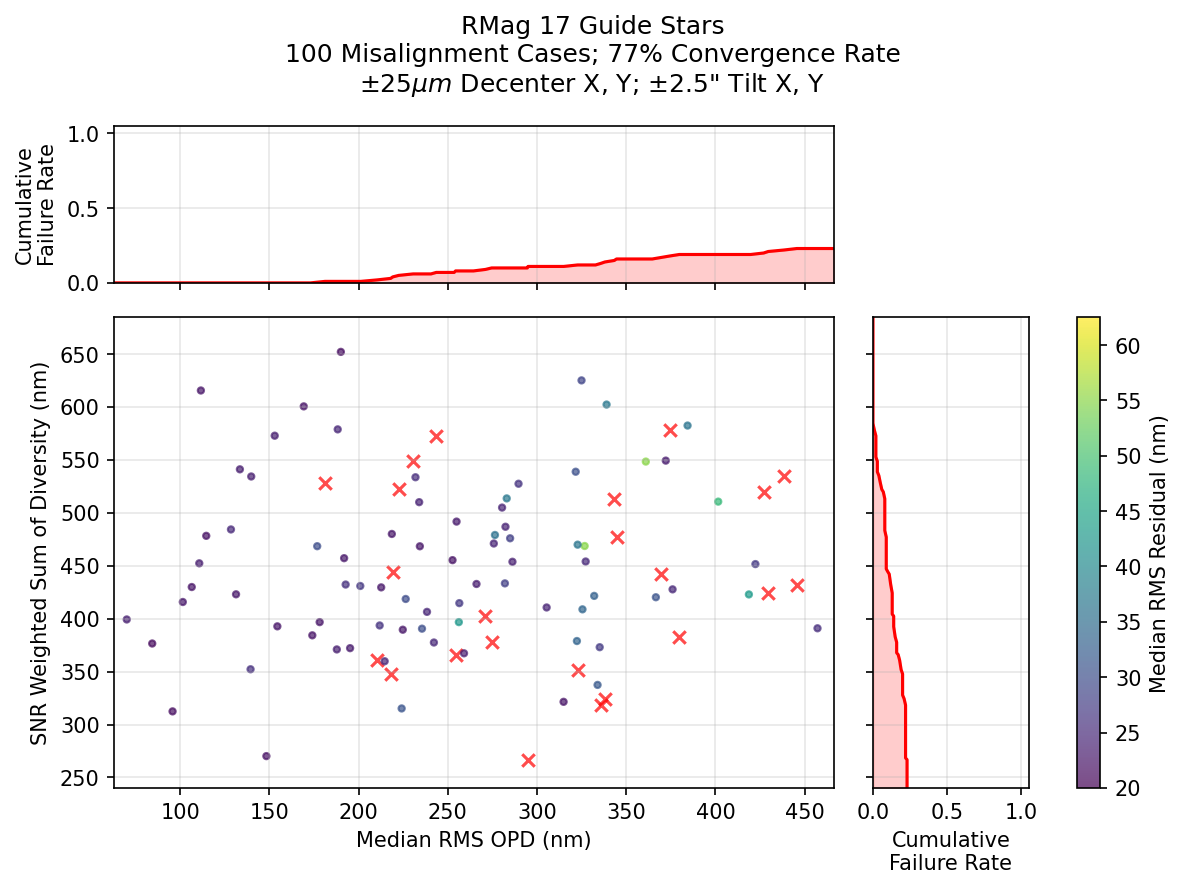

In [14]:
data = utils.load_pickle('/home/derbyk/src/ffpr/sim_results/20260505_mc_misalignments_5stars_dec_50um_tilt_5as.pkl')

median_rms_truth = np.zeros(len(data))
median_rms_residual = np.zeros(len(data))
max_rms_residual = np.zeros(len(data))
min_rms_residual = np.zeros(len(data))
std_rms_residual = np.zeros(len(data))
weighted_sum_diversity = np.zeros(len(data))

for i, case in enumerate(data):
    median_rms_truth[i] = np.median(np.array(data[case]['RMS_TRUTH_PER_FIELD']))
    median_rms_residual[i] = np.median(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    max_rms_residual[i] = np.max(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    min_rms_residual[i] = np.min(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    std_rms_residual[i] = np.std(np.array(data[case]['RMS_RESIDUAL_PER_FIELD']))
    median_snr = np.median(np.array(data[case]['SNR_PER_FIELD']))
    wsum = 0
    for snr, div in zip(data[case]['SNR_PER_FIELD'], data[case]['RMS_DIVERSITY_PER_FIELD']):
        wsum += snr / median_snr * div
    weighted_sum_diversity[i] = wsum

fig, axs = plt.subplot_mosaic([['histx', 'poop'],
                               ['scatter', 'histy']],
                               figsize=(8, 6), 
                               height_ratios=[1, 3],
                               width_ratios=[3, 1],
                               layout='tight',
                               dpi=150)

count = 0
fails_x = []
fails_y = []
xs = []
ys = []
cs = []

for x, y, c in zip(median_rms_truth, weighted_sum_diversity, median_rms_residual):
    if c < 62.5:
        xs.append(float(x))
        ys.append(float(y))
        cs.append(float(c))
    else:
        fails_x.append(float(x))
        fails_y.append(float(y))

xs = _np.array(xs)
ys = _np.array(ys)
cs = _np.array(cs)
fails_x = _np.array(fails_x)
fails_y = _np.array(fails_y)

xmin = _np.array([xs.min(), fails_x.min()]).min() * 0.9
xmax = _np.array([xs.max(), fails_x.max()]).max() * 1.02

ymin = _np.array([ys.min(), fails_y.min()]).min() * 0.9
ymax = _np.array([ys.max(), fails_y.max()]).max() * 1.05

cmin = 20
cmax = 62.5

sorted_fails_x = sorted(fails_x)
cdf_opd = [0]
cdf_x = [xmin ]
x = xmin
count = 0
while x < xmax:
    if count == len(fails_x):
        x += 10
        break
    if x + 10 < sorted_fails_x[count]:
        x += 10
        cdf_x.append(x)
        cdf_opd.append(cdf_opd[-1])
    else:
        x = sorted_fails_x[count]
        cdf_x.append(x)
        cdf_opd.append((((count + 1) / 100)))
        count += 1
cdf_x.append(xmax )
cdf_opd.append(cdf_opd[-1])
cdf_opd = _np.array(cdf_opd)
cdf_x = _np.array(cdf_x)

sorted_fails_y = _np.flip(sorted(fails_y))
cdf_snr = [0]
cdf_y = [ymax ]
y = ymax
count = 0
while y > ymin:
    if count == len(fails_y):
        y -= 10
        break
    if y - 10 > sorted_fails_y[count]:
        y -= 10
        cdf_y.append(y)
        cdf_snr.append(cdf_snr[-1])
    else:
        y = sorted_fails_y[count]
        cdf_y.append(y)
        cdf_snr.append((((count + 1) / 100)))
        count += 1
cdf_y.append(ymin )
cdf_snr.append(cdf_snr[-1])
cdf_snr = _np.array(cdf_snr)
cdf_y = _np.array(cdf_y)

axs['poop'].set_axis_off()

ax = axs['scatter']
ax.scatter(fails_x, fails_y, c='r', alpha=0.7, marker='x')
s = ax.scatter(xs, ys, c=cs, alpha=0.7, marker='.')
s.set_clim([cmin, cmax])
ax.set_xlabel('Median RMS OPD (nm)')
ax.set_ylabel('SNR Weighted Sum of Diversity (nm)')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([ymin , ymax ])
ax.grid(which='both', alpha=0.3)

plt.colorbar(s, ax=axs['histy'], pad=0.2, label='Median RMS Residual (nm)')

ax = axs['histx']
ax.plot(cdf_x, cdf_opd, color='r')
ax.fill_between(cdf_x, cdf_opd, alpha=0.2, color='r')
# ax.hist(np.array(fails_x).get(), bins=40, color='r')
ax.tick_params(axis='x', labelbottom=False)
ax.set_ylabel('Cumulative\nFailure Rate')
ax.set_xlim([xmin , xmax ])
ax.set_ylim([0, 1.05])
ax.grid(which='both', alpha=0.3)

ax = axs['histy']
ax.plot(cdf_snr, cdf_y, color='r')
ax.fill_betweenx(cdf_y, cdf_snr, alpha=0.2, color='r')
# ax.hist(np.array(fails_y).get(), bins=20, color='r', orientation='horizontal')
ax.tick_params(axis='y', labelleft=False)
ax.set_xticks([0, 0.5, 1])
ax.set_xlabel('Cumulative\nFailure Rate')
ax.set_ylim([ymin , ymax ])
ax.set_xlim([0, 1.05])
ax.grid(which='both', alpha=0.3)


fig.suptitle(f'RMag 17 Guide Stars\n{len(data):02.0f} Misalignment Cases; {len(cs) / len(data) * 100:02.0f}% Convergence Rate\n$\pm25\mu m$ Decenter X, Y; $\pm2.5$" Tilt X, Y')
